## Importing libraries and formatting plots

In [1]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

## Reading in analysis output file

In [2]:
multipliers = [1e-1, 3e-1, 1e0, 3e0, 1e1]
radii = 0.005 * np.array(multipliers)

df_list = []
thresholds_list = []
radius_list = []

one_e_4_list = []
three_e_4_list = []
one_e_3_list = []
three_e_3_list = []
one_e_2_list = []

for multiplier in multipliers:
    df = pd.read_csv(f'./Data Files/analysis_output_{multiplier:.0e}.csv')
    df_list.append(df)

    # Part 7 CSVs have 6 metadata columns (s1, s2, q2, alpha, source_radius, LD_coeff)
    # before the threshold columns, so thresholds start at column index 6.
    thresholds = np.array(df.columns[6:], dtype=float)
    thresholds_list.append(thresholds)

    radius = np.array(df['source_radius'].to_list())
    radius_list.append(radius)

    one_e_4 = np.array(df['1.1e-04'].to_list())
    one_e_4_list.append(one_e_4)

    three_e_4 = np.array(df['3.4e-04'].to_list())
    three_e_4_list.append(three_e_4)

    one_e_3 = np.array(df['1.0e-03'].to_list())
    one_e_3_list.append(one_e_3)

    three_e_3 = np.array(df['3.1e-03'].to_list())
    three_e_3_list.append(three_e_3)

    one_e_2 = np.array(df['1.1e-02'].to_list())
    one_e_2_list.append(one_e_2)

In [3]:
# Part 7 parameter space: s1 and q1 are fixed; s2, q2, and alpha vary.
ss_str_2 = np.array(df_list[0]['s2'].to_list(), dtype=str)
q2s = np.array(df_list[0]['q2'].to_list(), dtype=float)
alphas = np.array(df_list[0]['alpha'].to_list(), dtype=float)
ss_2 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s2'].to_list()])
s1 = '1.2'
q_1 = 1e-3

ss_str_unique_2 = np.array(['0.2', '0.5', '0.8', '1/0.8', '1/0.5', '1/0.2'], dtype=str)
ss_unique_2 = np.array([numexpr.evaluate(s) for s in ss_str_unique_2], dtype=float)
q2_unique = np.array([1e-4, 3e-4])
alpha_unique = np.array([0, 45, 90, 135, 180])

print(ss_str_unique_2)
print(q2_unique)
print(alpha_unique)

['0.2' '0.5' '0.8' '1/0.8' '1/0.5' '1/0.2']
[0.0001 0.0003]
[  0  45  90 135 180]


## Plotting fractional area above threshold as a function of threshold

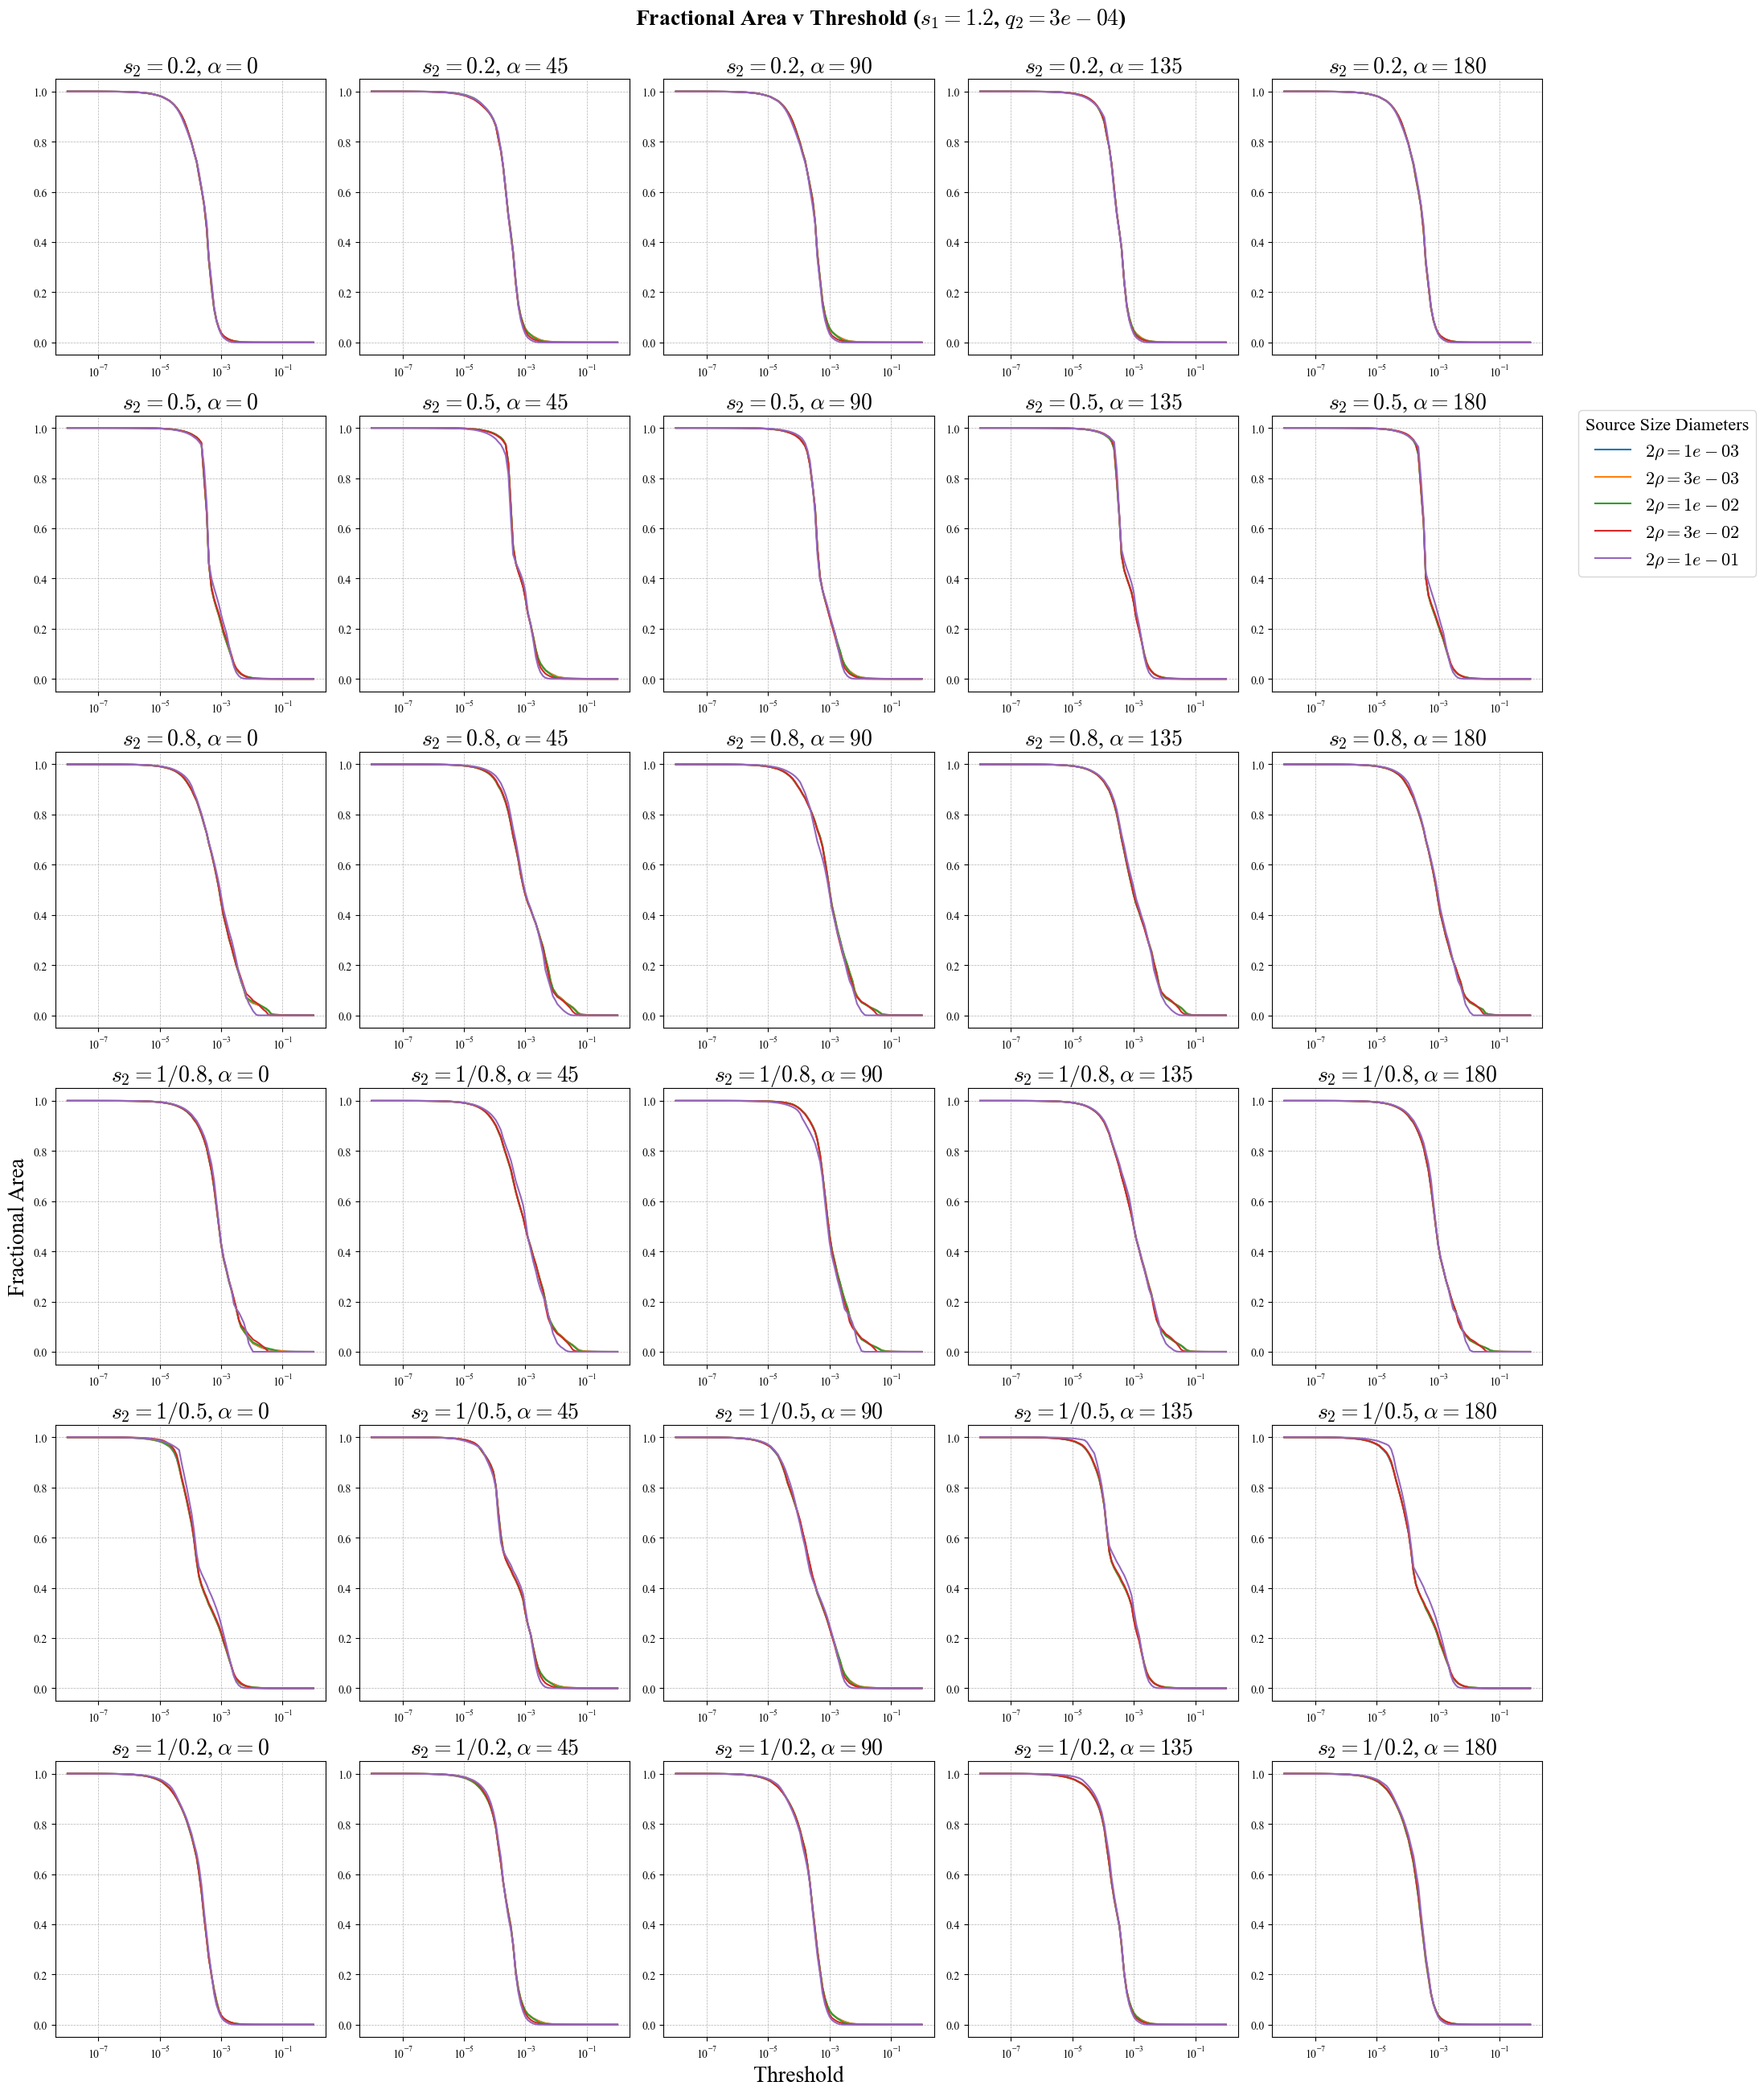

In [4]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(6, 5)

# Fixed small-planet mass ratio for this figure (toggle between q2_unique values)
q2 = 3e-4

fig.suptitle(f'Fractional Area v Threshold ($s_1 = {s1}$, $q_2 = {q2:.0e}$)', y=1.0)

for i, s2 in enumerate(ss_str_unique_2):
    for j, alpha in enumerate(alpha_unique):
        ax = axes[i, j]

        ax.set_title(f'$s_2={s2}$, $\\alpha={alpha}$')

        for k in range(len(multipliers)):
            df_subset = df_list[k][(df_list[k]['s2'] == s2) & (df_list[k]['q2'] == q2) & (df_list[k]['alpha'] == alpha)]
            ax.plot(thresholds, df_subset.iloc[0, 6:], label=f'$2\\rho = {2*radii[k]:.0e}$')

        ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Threshold')
axes[3, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Source Size Diameters')

# fig.savefig('./Figures/fractional_area_v_threshold.png', dpi=300)

plt.show()

## First, plotting fractional area as a function of source star radius for different thresholds

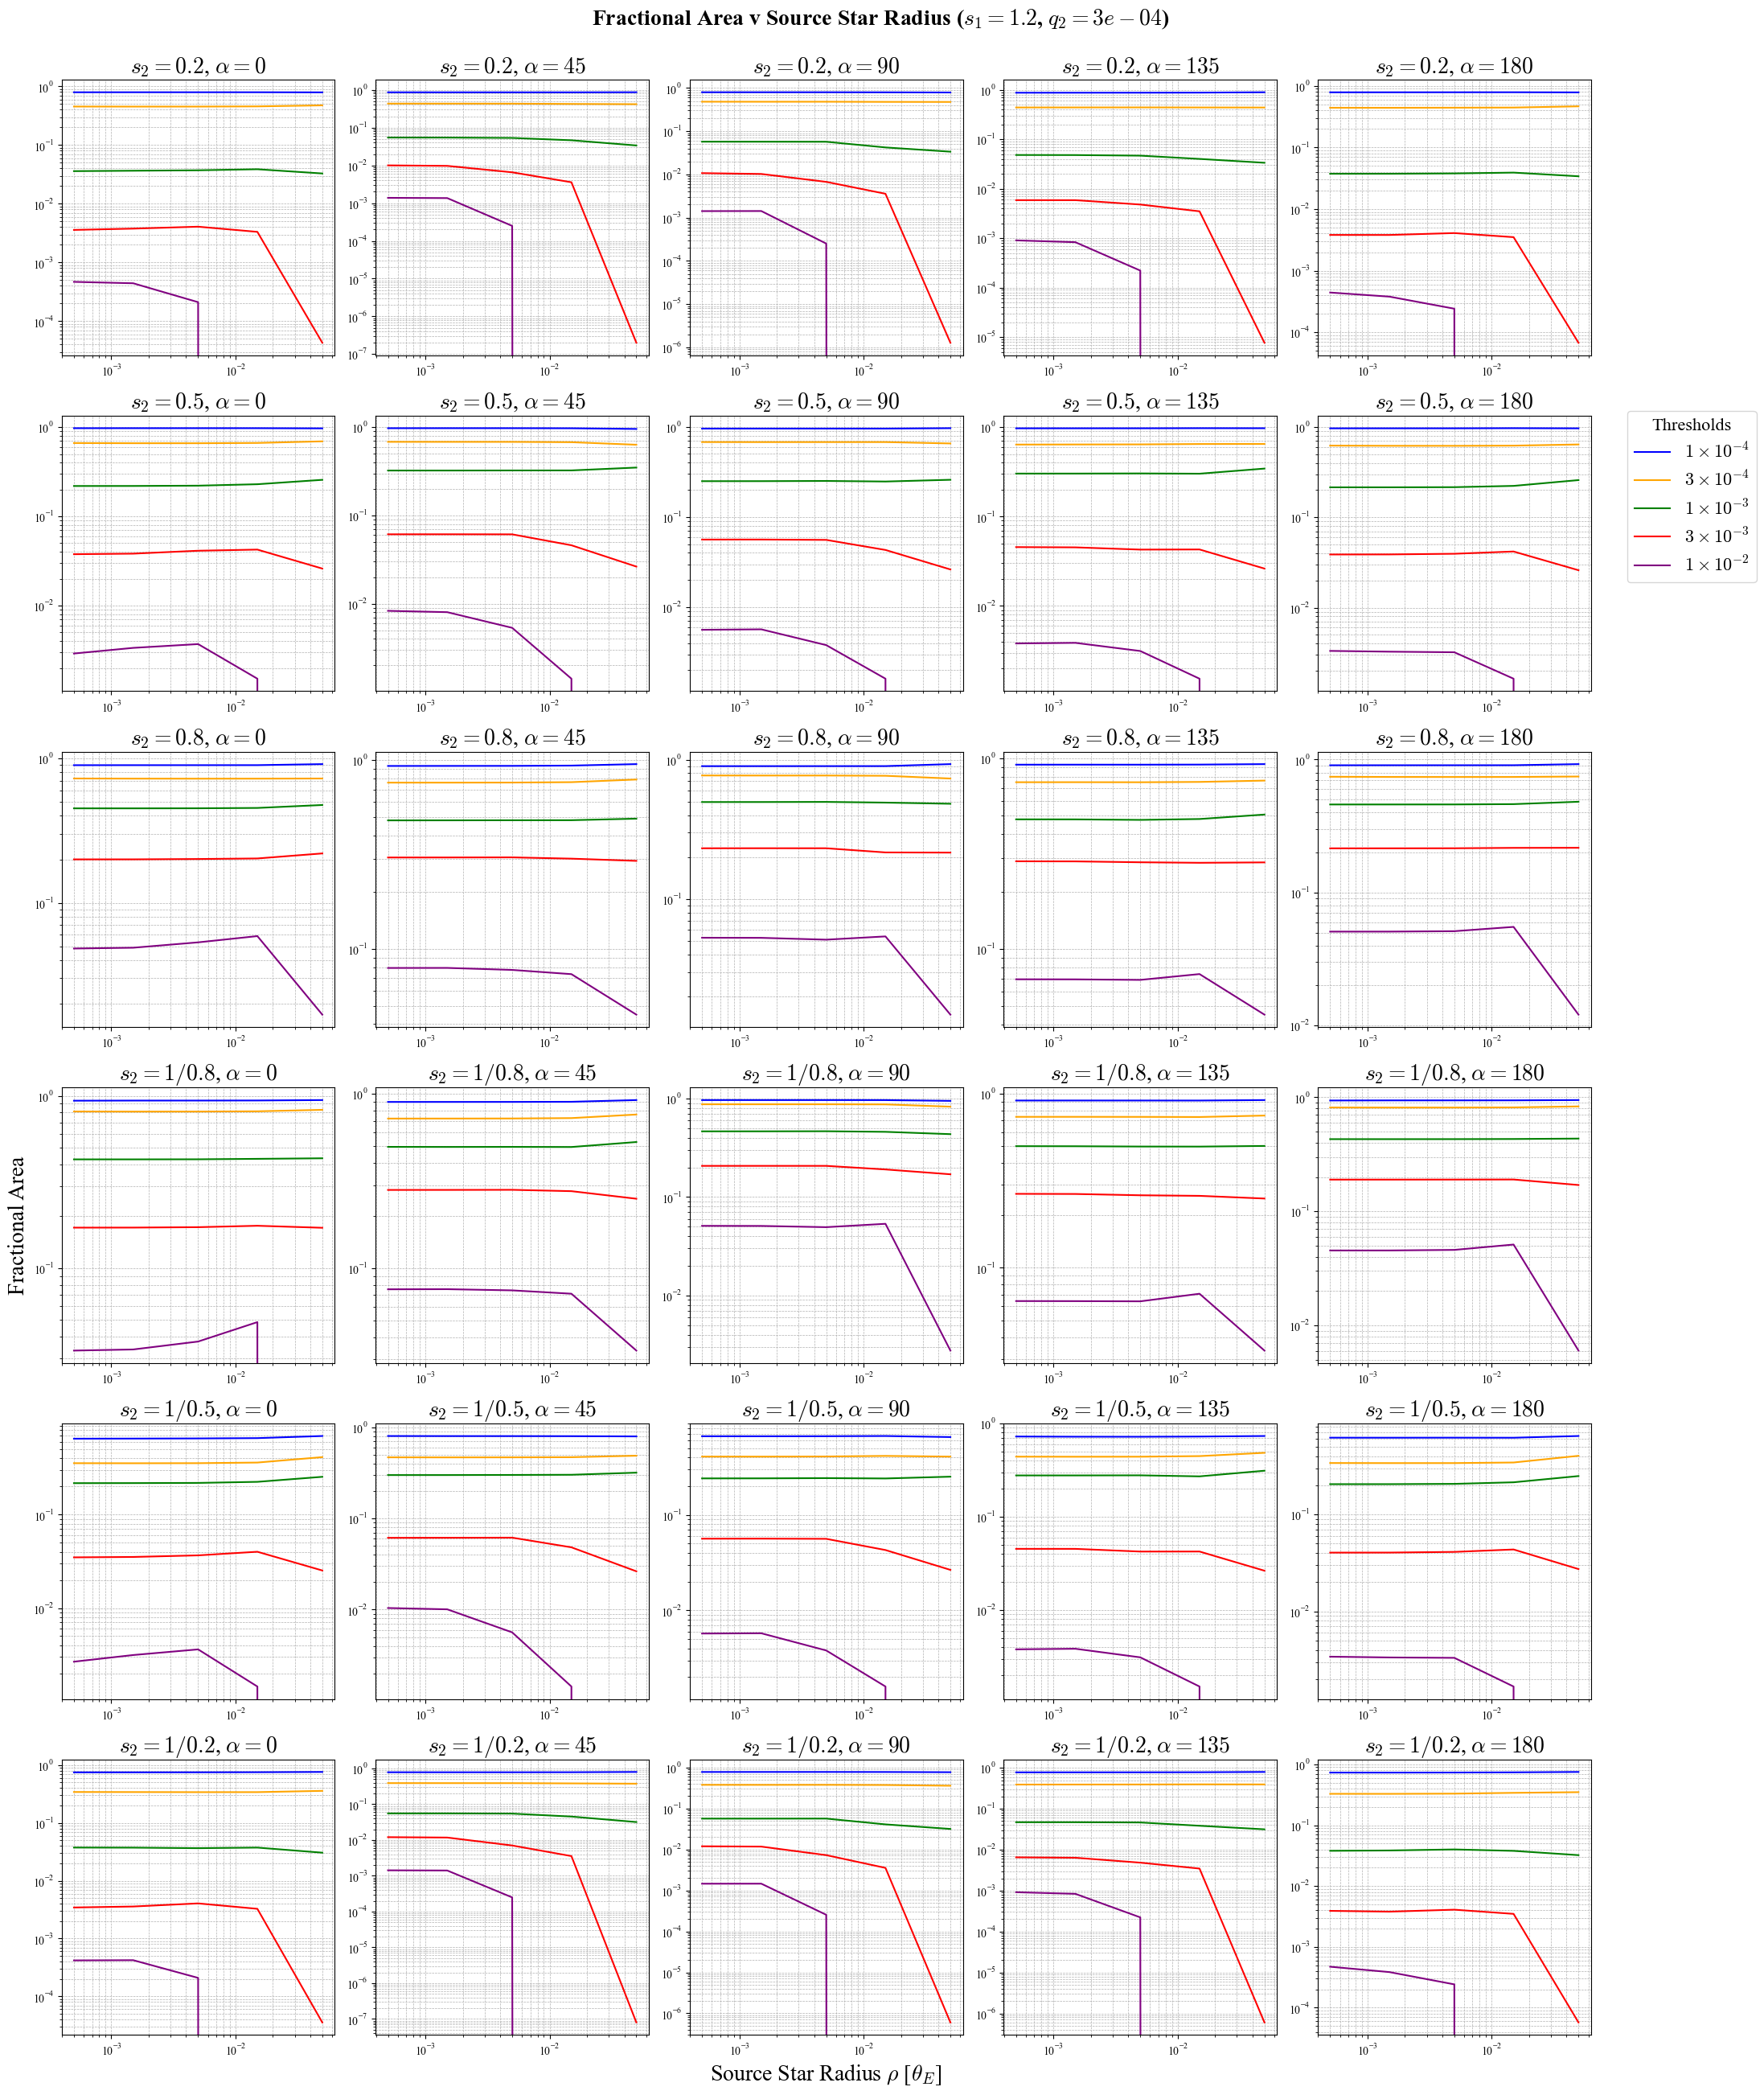

In [5]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(6, 5)

combined_df = pd.concat(df_list, ignore_index=True)

# Fixed small-planet mass ratio for this figure (toggle between q2_unique values)
q2 = 3e-4

fig.suptitle(f'Fractional Area v Source Star Radius ($s_1 = {s1}$, $q_2 = {q2:.0e}$)', y=1.0)

for i, s2 in enumerate(ss_str_unique_2):
    for j, alpha in enumerate(alpha_unique):
        ax = axes[i, j]

        ax.set_title(f'$s_2={s2}$, $\\alpha={alpha}$')

        df_subset = combined_df[(combined_df['s2'] == s2) & (combined_df['q2'] == q2) & (combined_df['alpha'] == alpha)]
        df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Source Star Radius $\\rho$ [$\\theta_E$]')
axes[3, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

# Second, plotting fractional area as a function of separation for different thresholds

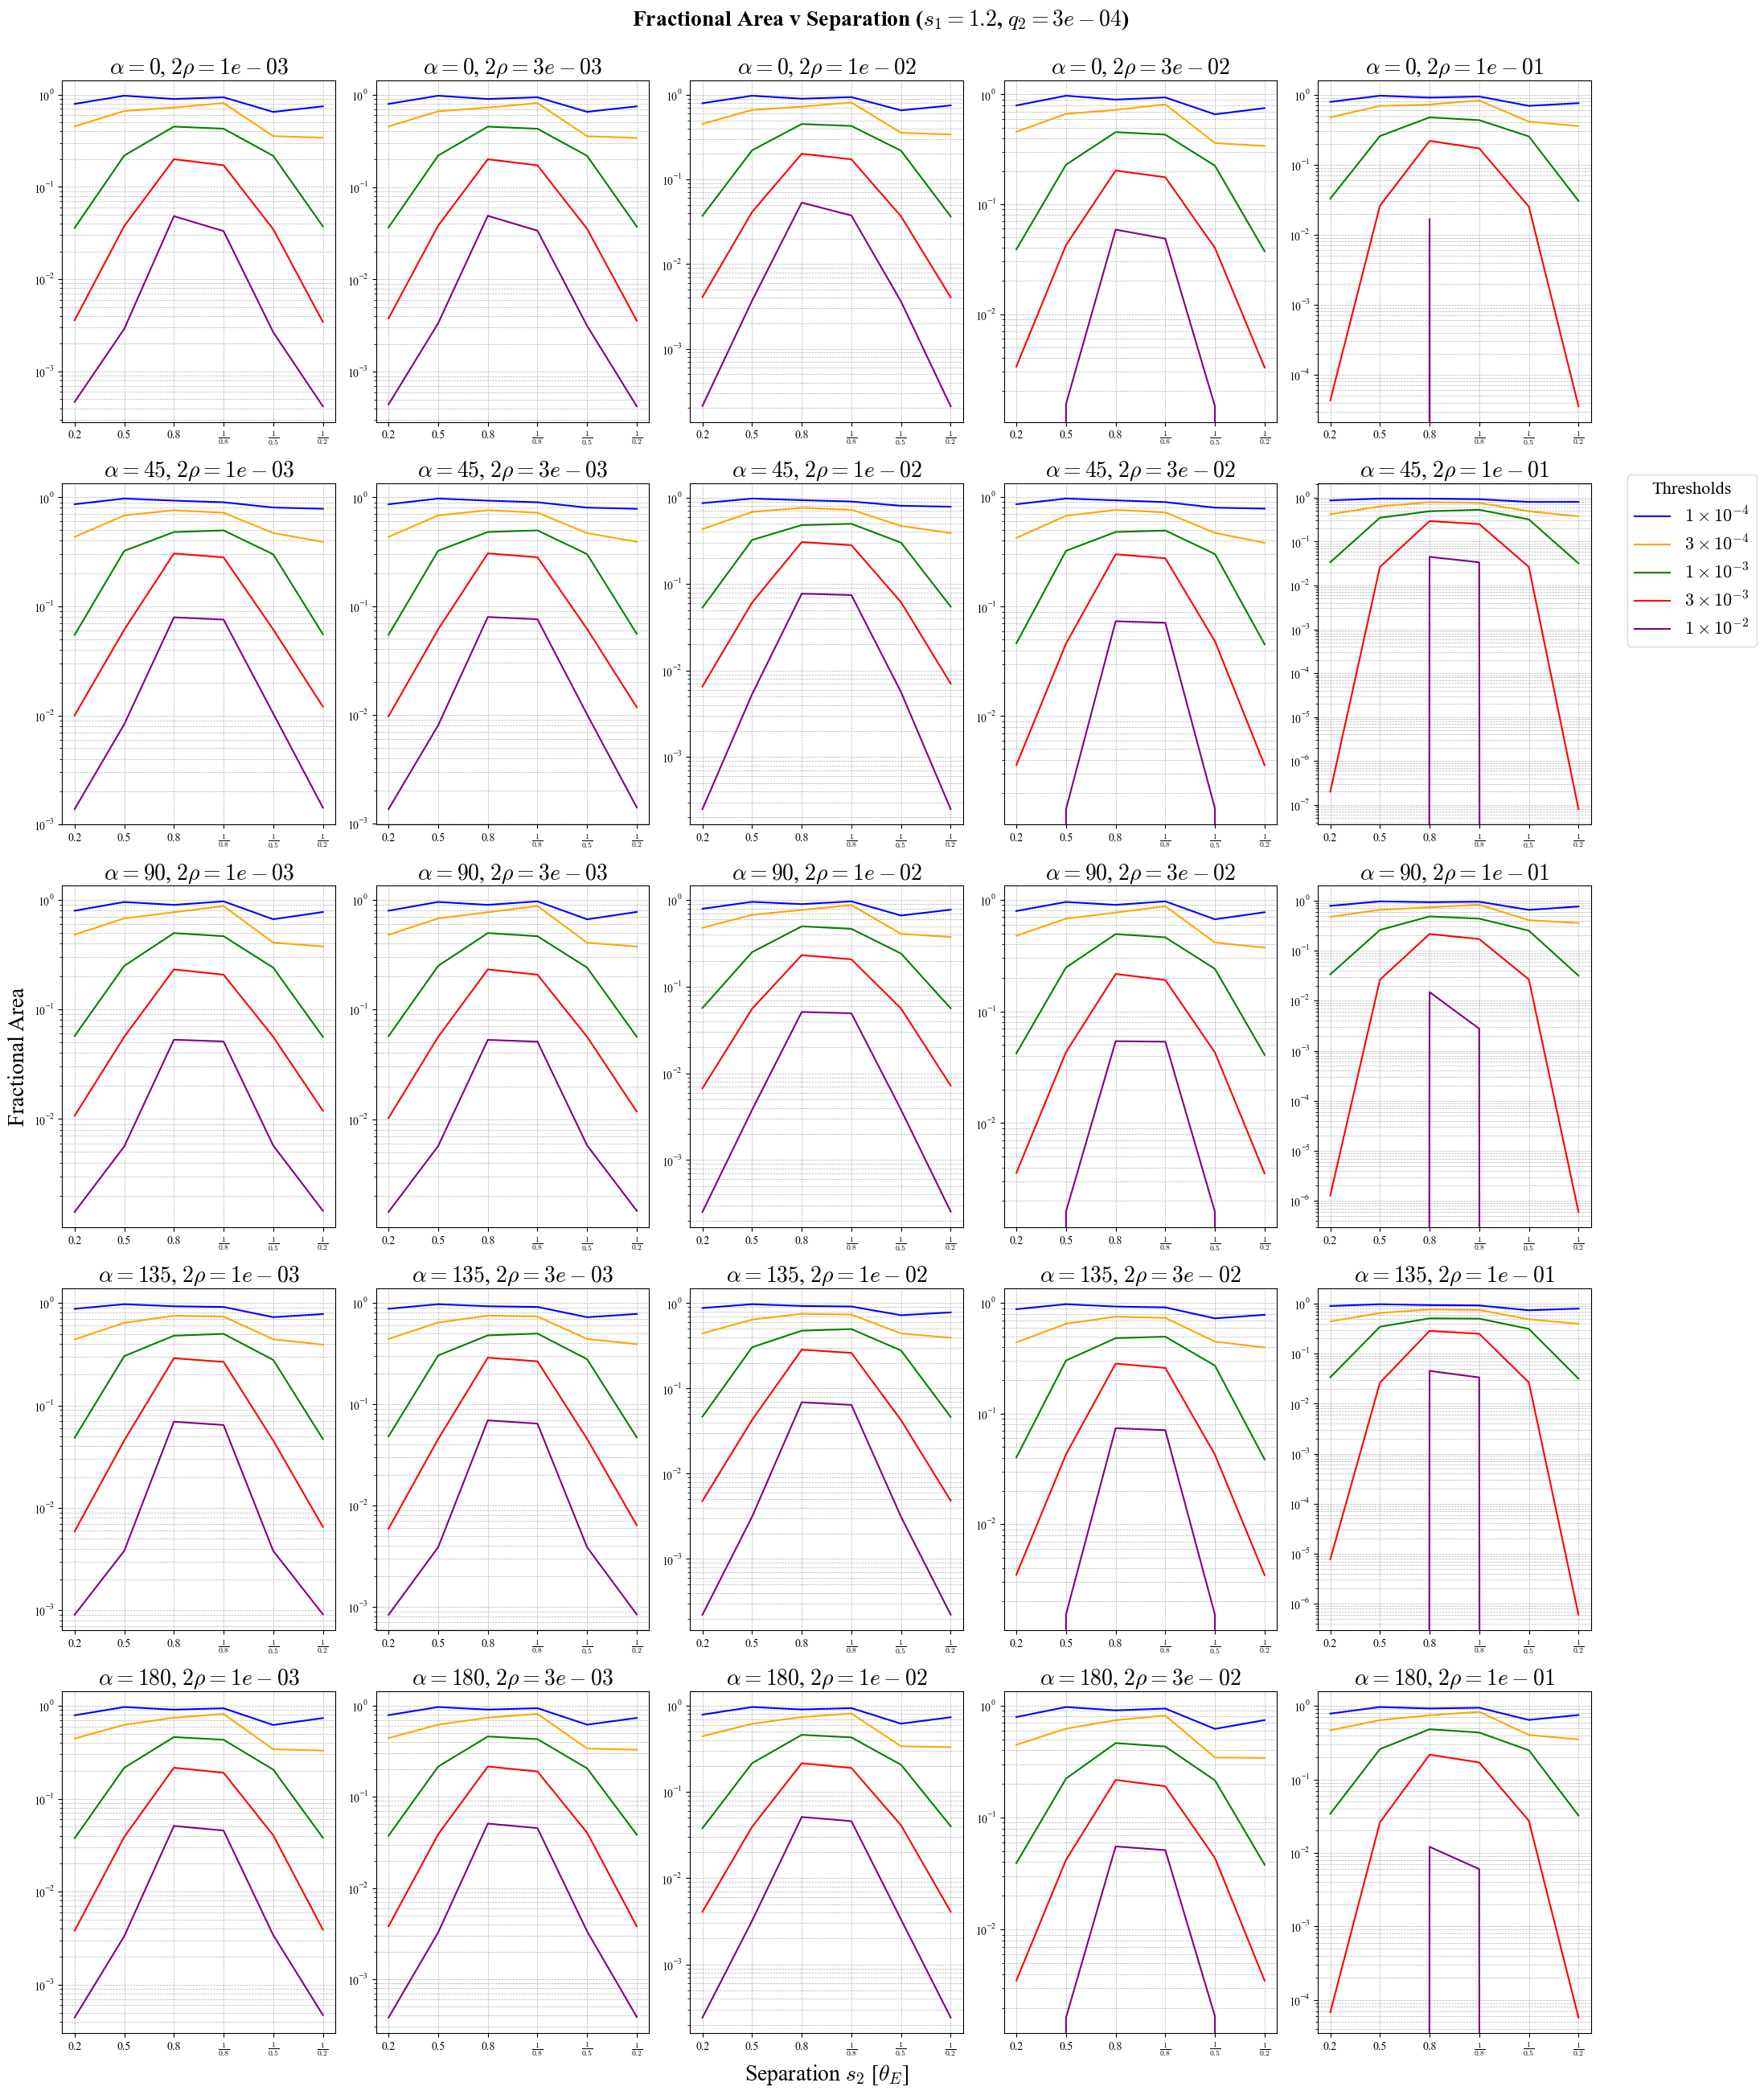

In [6]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

# Fixed small-planet mass ratio for this figure (toggle between q2_unique values)
q2 = 3e-4

fig.suptitle(f'Fractional Area v Separation ($s_1 = {s1}$, $q_2 = {q2:.0e}$)', y=1.0)

for i, alpha in enumerate(alpha_unique):
    for j, radius in enumerate(radii):
        ax = axes[i, j]

        ax.set_title(f'$\\alpha={alpha}$, $2\\rho = {2*radius:.0e}$')

        df_subset = df_list[j][(df_list[j]['q2'] == q2) & (df_list[j]['alpha'] == alpha)]
        # Rows come out in s2 order matching ss_str_unique_2

        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, len(ss_str_unique_2)))

        # Using stacked fractions for the x-ticks to show separation values instead of indices
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_2])

axes[-1, 2].set_xlabel('Separation $s_2$ [$\\theta_E$]')
axes[2, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

# fig.savefig('./Figures/fractional_area_v_separation.png', dpi=300)

plt.show()

## Detectability as a function of $s_2$ and $\alpha$ for different thresholds

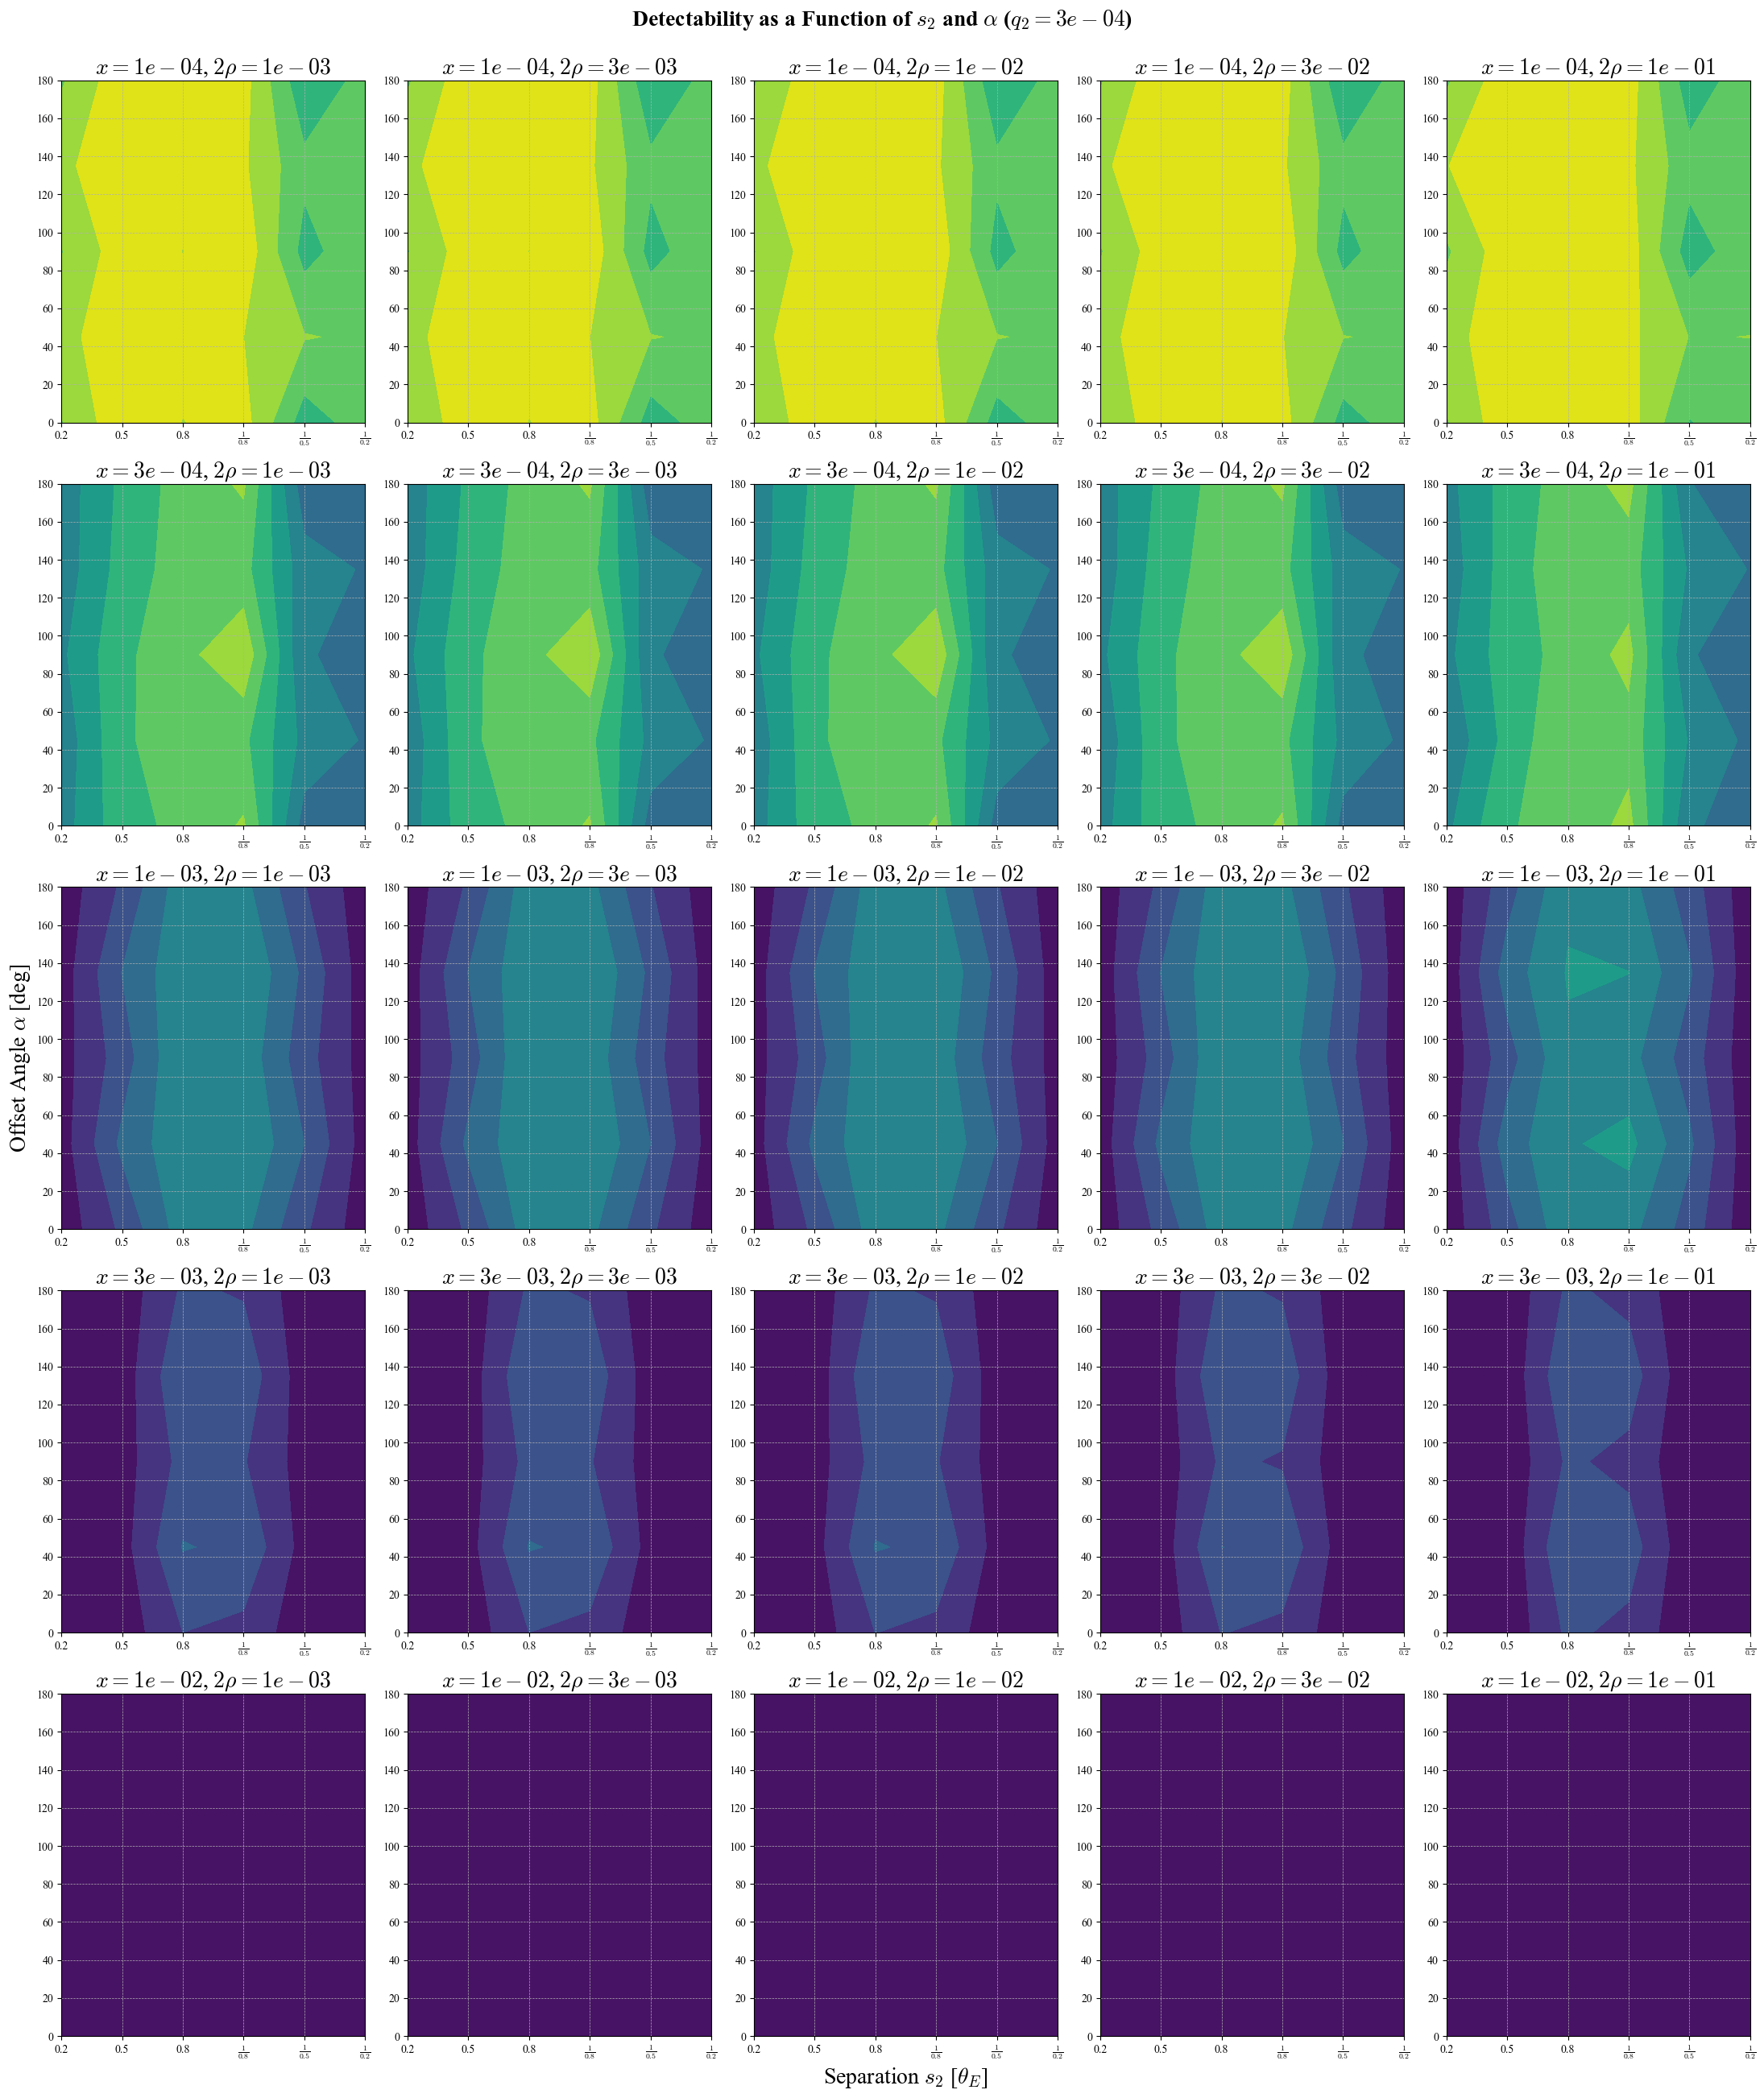

In [7]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

# Fixed small-planet mass ratio for this figure (toggle between q2_unique values)
q2 = 3e-4

fig.suptitle(f'Detectability as a Function of $s_2$ and $\\alpha$ ($q_2 = {q2:.0e}$)', y=1.0)

for i, threshold in enumerate([1.1e-04, 3.4e-04, 1.0e-03, 3.1e-03, 1.1e-02]):
    for j, radius in enumerate(radii):
        ax = axes[i, j]

        ax.set_title(f'$x={threshold:.0e}$, $2\\rho = {2*radius:.0e}$')

        df_subset = df_list[j][(df_list[j]['q2'] == q2)]

        # df_subset rows are ordered s2 (outer) then alpha (inner) -> reshape (n_s2, n_alpha),
        # transpose so contourf gets Z of shape (len(y=alpha), len(x=s2)).
        ax.contourf(
            np.linspace(0, 1, len(ss_str_unique_2)),
            alpha_unique,
            np.array(df_subset[f'{threshold:.1e}']).reshape((len(ss_str_unique_2), len(alpha_unique))).T,
            levels=np.linspace(0, 1, 11),
            cmap='viridis',
            # vmin=0, vmax=1
        )

        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, len(ss_str_unique_2)))
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_2])

axes[-1, 2].set_xlabel('Separation $s_2$ [$\\theta_E$]')
axes[2, 0].set_ylabel('Offset Angle $\\alpha$ [deg]')

plt.show()

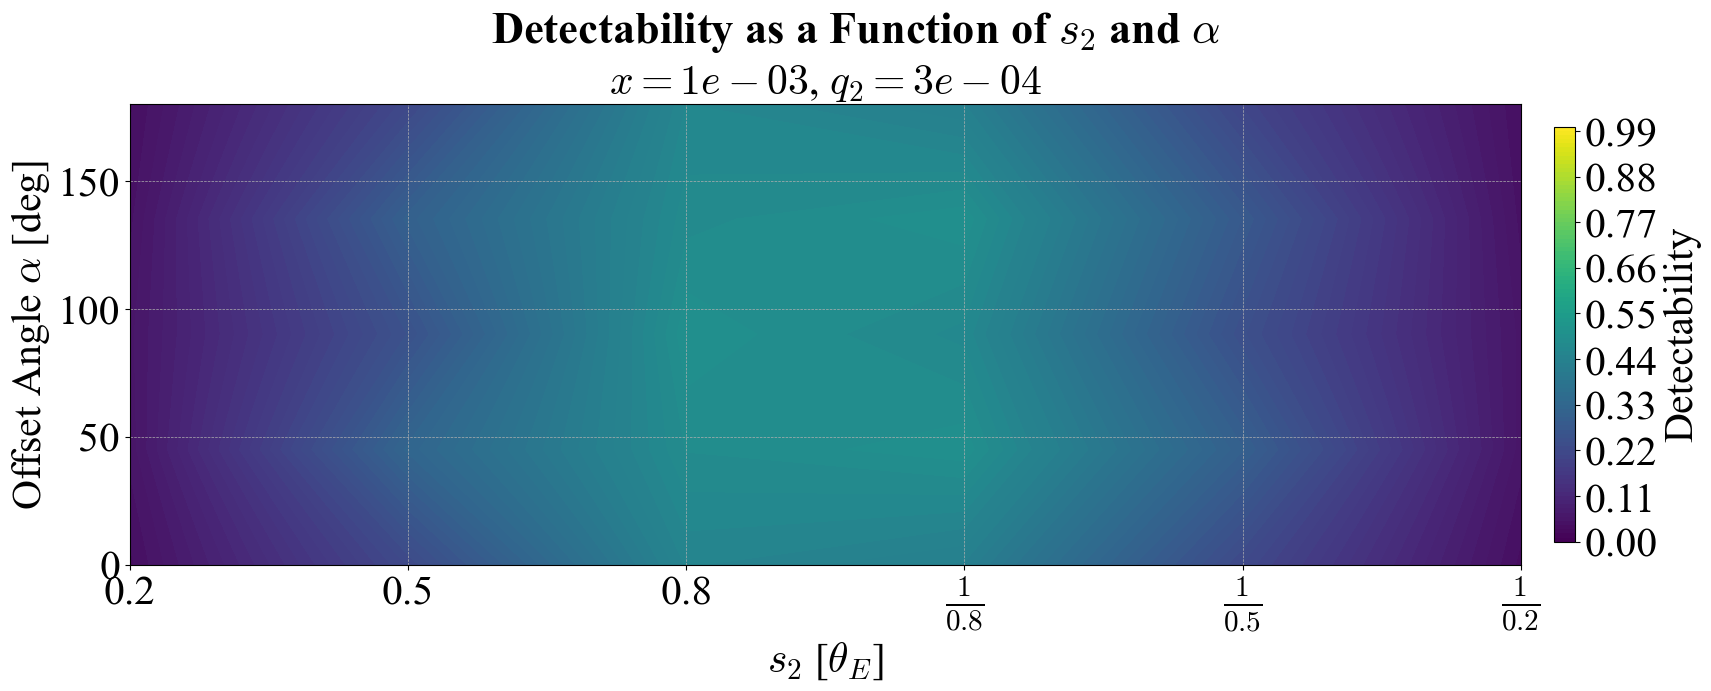

In [8]:
# Setting up plotting style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['figure.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 28
plt.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(17, 6.8))
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Detectability as a Function of $s_2$ and $\\alpha$')

threshold = 1.0e-03
multiplier = 1.00e0
q2 = 3e-4

ax.set_title(f'$x={threshold:.0e}$, $q_2 = {q2:.0e}$')

df_subset = df_list[2][(df_list[2]['q2'] == q2)]

img = ax.contourf(
    np.linspace(0, 1, len(ss_str_unique_2)),
    alpha_unique,
    np.array(df_subset[f'{threshold:.1e}']).reshape((len(ss_str_unique_2), len(alpha_unique))).T,
    levels=np.linspace(0, 1, 101),
    cmap='viridis',
    # vmin=0, vmax=1
)

bar = fig.colorbar(img, ax=ax, shrink=0.9, pad=0.01, label='Detectability')

ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xticks(np.linspace(0, 1, len(ss_str_unique_2)))
ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_2])

ax.set_xlabel('$s_2$ [$\\theta_E$]')
ax.set_ylabel('Offset Angle $\\alpha$ [deg]')

# fig.savefig('./Figures/Detectability_s2_alpha.png', dpi=300, bbox_inches='tight')

plt.show()